In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
df = pd.read_csv('C://Users//wenzh//Desktop//deep_learning//data//Model_construction_data.csv')

In [4]:
combined_df = df

In [ ]:
with open('columns_1_to_8.txt', 'w', encoding='utf-8') as f:
    for index, row in df.iloc[:, :8].iterrows():  # iloc[:, :8] selects the first 8 columns (with indices commencing from 0)
        line = '\t'.join(str(val) for val in row)  # Delimit column values with tabs
        f.write(line + '\n')

In [6]:
combined_df

,ID,Label,cdr3_aa1,cdr3_aa2,CTgene,HPV,Celltype,pMT,AL627309.1,AL669831.5,...,ATP5J,AF131217.1,C21orf59,ATP5O,DSCR3,AP001610.5,AP001046.5,TRAPPC10,C21orf33,AP001055.6
0,HPV15_KSA_Tumor_AAACGGGAGAGTCGGT-1,Neo,CAVHSGGGADGLTF,CASSMMGQIDVLTF,TRAV41.TRAJ45.TRBV19.TRBD1.TRBJ2-6,1,GZMK+ Tex,3.306233,0.000243,0.011174,...,-0.066742,-0.003164,-0.025064,-0.007775,-0.015266,-0.001440,-0.002115,-0.009416,-0.001630,-0.001583
1,HPV15_KSA_Tumor_AAACGGGAGGTAAACT-1,Neo,CAVHSGGGADGLTF,CASSMMGQIDVLTF,TRAV41.TRAJ45.TRBV19.TRBD1.TRBJ2-6,1,GZMK+ Tex,3.124345,-0.000593,-0.020459,...,0.115298,0.005904,0.044678,0.013871,0.027081,0.002469,0.004010,0.017737,0.002883,0.002832
2,HPV15_KSA_Tumor_AAACGGGGTGCTTCTC-1,Neo,CAVHSGGGADGLTF,CASSMMGQIDVLTF,TRAV41.TRAJ45.TRBV19.TRBD1.TRBJ2-6,1,GZMK+ Tex,2.000531,-0.000030,-0.001665,...,0.007778,0.000467,0.003548,0.000907,0.001909,0.000186,0.000264,0.001359,0.000159,0.000231
3,HPV15_KSA_Tumor_AAACGGGTCCATGAAC-1,Neo,CAVHSGGGADGLTF,CASSMMGQIDVLTF,TRAV41.TRAJ45.TRBV19.TRBD1.TRBJ2-6,1,GZMK+ early Tem,1.898546,-0.000524,-0.018147,...,0.099264,0.005129,0.038755,0.011970,0.023421,0.002121,0.003474,0.015430,0.002477,0.002461
4,HPV15_KSA_Tumor_AAAGATGTCTGGCGTG-1,Neo,CAVHSGGGADGLTF,CASSMMGQIDVLTF,TRAV41.TRAJ45.TRBV19.TRBD1.TRBJ2-6,1,GZMK+ Tex,2.537486,0.000349,0.011818,...,-0.055467,-0.002973,-0.022442,-0.006807,-0.013326,-0.001167,-0.002033,-0.009132,-0.001375,-0.001425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44687,18_P31_ACGCAGCGTCGCGGTT-1,nonNeo,CAATASGGSYIPTF,CAIGTGDSNQPQHF,TRAV1-2.TRAJ6.TRBV10-3.TRBD1.TRBJ1-5,1,GZMK+ early Tem,0.671517,-0.000220,-0.006420,...,0.007114,0.000978,0.006645,0.001298,0.002764,0.000152,0.000632,0.003436,0.000094,0.000430
44688,18_P31_CATGCCTGTCTAGGTT-1,nonNeo,CAVEEDKAAGNKLTF,CASSLGSYNEQFF,TRAV22.TRAJ17.TRBV7-6.NA.TRBJ2-1,1,GZMK+ early Tem,0.696460,0.000176,0.006465,...,-0.022600,-0.002208,-0.016703,-0.005341,-0.010466,-0.000982,-0.001474,-0.006401,-0.001157,-0.001066
44689,18_P31_CAGCCGAGTGTAATGA-1,nonNeo,CAATASGGSYIPTF,CAIGTGDSNQPQHF,TRAV1-2.TRAJ6.TRBV10-3.TRBD1.TRBJ1-5,1,IL7R+ Tm,0.984366,0.001332,0.046853,...,-0.254721,-0.013746,-0.104754,-0.033097,-0.064422,-0.005910,-0.009387,-0.041061,-0.007009,-0.006637
44690,18_P31_TGACGGCTCCCTAATT-1,nonNeo,CATDDNYGQNFVF,CASSIDWPGIYGYTF,TRAV17.TRAJ26.TRBV19.NA.TRBJ1-2,1,GZMK+ early Tem,1.334223,0.000283,0.012086,...,-0.107288,-0.004920,-0.037973,-0.012475,0.000302,-0.002330,-0.003353,-0.014191,-0.002741,-0.002387


In [ ]:
# Load metadata and merge patient_id
df1 = pd.read_csv('input_meta-Molecular_cell.csv')[['ID', 'Label', 'patient_id']]
df1 = df1[df1['ID'].isin(combined_df['ID'])]
combined_df = combined_df.merge(df1[['ID', 'patient_id']], on='ID', how='left')
# Calculate the number of samples and the proportion of positive examples for each patient
patient_stats = df1.groupby('patient_id').agg(
    total_samples=('Label', 'count'),
    positive_ratio=('Label', lambda x: (x == 'Neo').mean())
).reset_index()

In [8]:
# Add the sample ID list for each patient (for subsequent splitting).
patient_ids_to_samples = df1.groupby('patient_id')['ID'].apply(list).to_dict()
patient_stats['samples'] = patient_stats['patient_id'].map(patient_ids_to_samples)
test_size=0.2
max_iter=10000
# Setting a random seed to ensure reproducibility
np.random.seed(666)

In [9]:
best_diff = float('inf')
best_train = None
best_test = None

In [10]:
# Reference value of overall positive case ratio
overall_positive_ratio = (df1['Label'] == 'Neo').mean()
for _ in range(max_iter):
    # Randomly shuffle patients
    shuffled = patient_stats.sample(frac=1)  
    # Accumulate patients in shuffled order
    cum_samples = 0
    cum_positive = 0
    train_patients = []   
    for _, row in shuffled.iterrows():
        # Calculate the statistics after the current patient joins
        new_total = cum_samples + row['total_samples']
        new_positive = cum_positive + row['positive_ratio'] * row['total_samples']     
        # Check if the test set size tolerance is exceeded
        if abs(1 - new_total / len(df1) - test_size) > 0.05:  # 5% tolerance
            train_patients.append(row)
            cum_samples = new_total
            cum_positive = new_positive
        else:
            break 
    # Create a test set (remaining patients)
    test_patients = shuffled[~shuffled['patient_id'].isin([p['patient_id'] for p in train_patients])]  
    # Calculate the proportion of positive examples in the training set
    if cum_samples == 0:
        train_ratio = 0
    else:
        train_ratio = cum_positive / cum_samples  
    # Calculate the proportion of positive examples in the test set
    test_positive = (df1[df1['patient_id'].isin(test_patients['patient_id'])]['Label'] == 'Neo').sum()
    test_ratio = test_positive / (len(df1) - cum_samples) if cum_samples < len(df1) else 0 
    # Evaluating distribution differences
    diff = abs(train_ratio - test_ratio)  
    # Check if a better split is found
    if diff < best_diff:
        best_diff = diff
        best_train = train_patients
        best_test = test_patients

In [11]:
# Extract sample ID
train_ids = [sample for p in best_train for sample in p['samples']]
try:
    test_ids = [sample for p in best_test for sample in p['samples']]
except:
    test_ids = []
    for sample in best_test['samples']:
        test_ids.extend((sample))

In [12]:
train_set = df[df['ID'].isin(train_ids)].copy()
test_set = df[df['ID'].isin(test_ids)].copy()
# Verification results
print(f"Training set size: {len(train_set)} samples")
print(f"Test set size: {len(test_set)} samples")
print(f"Training set positive example ratio: {100*(train_set['Label']=='Neo').mean():.2f}%")
print(f"Test set positive example ratio: {100*(test_set['Label']=='Neo').mean():.2f}%")
train_index = train_set.index
test_index = test_set.index

Training set size: 30871 samples
Test set size: 13821 samples
Training set positive example ratio: 27.43%
Test set positive example ratio: 27.43%


In [13]:
def process_CTgene(df):
    default_TRBD = "NA"
    split_genes = df['CTgene'].str.split('.', expand=True)
    split_genes = split_genes.reindex(columns=[0, 1, 2, 3, 4], fill_value=default_TRBD)
    split_genes.columns = ['TRAV', 'TRAJ', 'TRBV', 'TRBD', 'TRBJ']
    split_genes['TRBD'] = split_genes['TRBD'].apply(lambda x: x if isinstance(x, str) and x.startswith("TRBD") else default_TRBD)
    split_genes['TRBJ'] = split_genes['TRBJ'].apply(lambda x: x if isinstance(x, str) and not x.startswith("TRBD") else default_TRBD)
    df[['TRAV', 'TRAJ', 'TRBV', 'TRBD', 'TRBJ']] = split_genes
    return df

In [14]:
def create_gene_index_mapping(df, column_name, unknown_token='UNK'):
    gene_types = df[column_name].astype(str).unique()
    gene_to_idx = {gene: idx for idx, gene in enumerate(gene_types)}
    gene_to_idx[unknown_token] = len(gene_to_idx)
    return gene_to_idx

In [15]:
def encode_cdr3_sequence_properties(seq, max_len):
    non_polar_non_aromatic = ['A', 'I', 'L', 'M', 'V', 'G', 'P']
    aromatic = ['F', 'W', 'Y']
    polar_non_aromatic = ['S', 'T', 'N', 'Q', 'C']
    negative_charged = ['D', 'E']
    positive_charged = ['R', 'K', 'H']
    features = np.zeros(max_len)
    for i, aa in enumerate(seq):
        if i >= max_len:
            break
        if aa in non_polar_non_aromatic:
            features[i] = 1
        elif aa in aromatic:
            features[i] = 2
        elif aa in polar_non_aromatic:
            features[i] = 3
        elif aa in negative_charged:
            features[i] = 4
        elif aa in positive_charged:
            features[i] = 5
    return features

In [16]:
def pretreatment(df, trav_to_idx=None, traj_to_idx=None, trbv_to_idx=None, trbd_to_idx=None, trbj_to_idx=None, cell_to_idx=None, is_train=False):
    df['CTgene'] = df['CTgene'].str.replace('_', '.', regex=False)
    if 'patient_id' in df.columns:
        gene_columns = df.columns[df.columns.get_loc('pMT'): df.columns.get_loc('patient_id')]
    else:
        gene_columns = df.columns[df.columns.get_loc('pMT'):]
    X_genes = df[gene_columns].values.astype(float)
    if 'Label' in df.columns:
        df['Label_num'] = df['Label'].map({'Neo': 1, 'nonNeo': 0})
        y = df['Label_num'].values.copy()
        df = df.drop(labels=['Label_num', 'Label'], axis=1)
    else:
        y = None
    if df['HPV'].dtype == object:
        df['HPV_num'] = df['HPV'].map({'HPV+': 1, 'HPV-': 0})
    else:
        df['HPV_num'] = df['HPV']
    if cell_to_idx is None or is_train:
        cell_types = df['Celltype'].astype(str).unique()
        cell_to_idx = {cell: idx for idx, cell in enumerate(cell_types)}
    df['celltype_idx'] = df['Celltype'].astype(str).map(cell_to_idx).fillna(-1).astype(int)
    df = process_CTgene(df)
    if trav_to_idx is None or is_train:
        trav_to_idx = create_gene_index_mapping(df, 'TRAV')
    if traj_to_idx is None or is_train:
        traj_to_idx = create_gene_index_mapping(df, 'TRAJ')
    if trbv_to_idx is None or is_train:
        trbv_to_idx = create_gene_index_mapping(df, 'TRBV')
    if trbd_to_idx is None or is_train:
        trbd_to_idx = create_gene_index_mapping(df, 'TRBD')
    if trbj_to_idx is None or is_train:
        trbj_to_idx = create_gene_index_mapping(df, 'TRBJ')
    df['TRAV_idx'] = df['TRAV'].map(trav_to_idx).fillna(trav_to_idx['UNK']).astype(int)
    df['TRAJ_idx'] = df['TRAJ'].map(traj_to_idx).fillna(traj_to_idx['UNK']).astype(int)
    df['TRBV_idx'] = df['TRBV'].map(trbv_to_idx).fillna(trbv_to_idx['UNK']).astype(int)
    df['TRBD_idx'] = df['TRBD'].map(trbd_to_idx).fillna(trbd_to_idx['UNK']).astype(int)
    df['TRBJ_idx'] = df['TRBJ'].map(trbj_to_idx).fillna(trbj_to_idx['UNK']).astype(int)
    MAX_LEN_ALPHA = 21
    MAX_LEN_BETA = 26
    df['seq_alpha_encoded_props'] = df['cdr3_aa1'].apply(lambda s: encode_cdr3_sequence_properties(s, MAX_LEN_ALPHA))
    df['seq_beta_encoded_props'] = df['cdr3_aa2'].apply(lambda s: encode_cdr3_sequence_properties(s, MAX_LEN_BETA))
    df['seq_alpha_len'] = df['cdr3_aa1'].apply(len)
    df['seq_beta_len'] = df['cdr3_aa2'].apply(len)
    X_seq_alpha_props = df['seq_alpha_encoded_props'].apply(lambda x: torch.tensor(x, dtype=torch.long)).tolist()
    X_seq_beta_props = df['seq_beta_encoded_props'].apply(lambda x: torch.tensor(x, dtype=torch.long)).tolist()
    X_seq_alpha_len = df['seq_alpha_len'].values
    X_seq_beta_len = df['seq_beta_len'].values
    X_ctgene = df[['TRAV_idx', 'TRAJ_idx', 'TRBV_idx', 'TRBD_idx', 'TRBJ_idx']].values
    X_celltype = df['celltype_idx'].values
    X_hpvinf = df['HPV_num'].values
    to_idx = [trav_to_idx, traj_to_idx, trbv_to_idx, trbd_to_idx, trbj_to_idx, cell_to_idx]
    return to_idx, X_genes, X_ctgene, X_celltype, X_hpvinf, X_seq_alpha_props, X_seq_beta_props, X_seq_alpha_len, X_seq_beta_len, y

In [17]:
class TCellDataset(Dataset):
    def __init__(self, X_gene, X_ct, X_cell, X_hpv, X_seq_a_props, X_seq_b_props, X_seq_a_len, X_seq_b_len, y=None):
        self.X_gene = torch.tensor(X_gene, dtype=torch.float32)
        self.X_ctgene = torch.tensor(X_ct, dtype=torch.long)
        self.X_cell = torch.tensor(X_cell, dtype=torch.long)
        self.X_hpv = torch.tensor(X_hpv, dtype=torch.long)
        self.X_seq_alpha_props = torch.tensor(np.array(X_seq_a_props), dtype=torch.long)
        self.X_seq_beta_props = torch.tensor(np.array(X_seq_b_props), dtype=torch.long)
        self.X_seq_alpha_len = torch.tensor(np.array(X_seq_a_len), dtype=torch.float32)
        self.X_seq_beta_len = torch.tensor(np.array(X_seq_b_len), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None

    def __len__(self):
        return len(self.X_gene)

    def __getitem__(self, idx):
        item = (self.X_gene[idx], self.X_ctgene[idx], self.X_cell[idx], self.X_hpv[idx],
                self.X_seq_alpha_props[idx], self.X_seq_beta_props[idx], self.X_seq_alpha_len[idx], self.X_seq_beta_len[idx])
        if self.y is not None:
            return item + (self.y[idx],)
        return item

In [18]:
train_set = combined_df[combined_df['ID'].isin(train_ids)].copy()
test_set = combined_df[combined_df['ID'].isin(test_ids)].copy()

In [19]:
# Preprocess with is_train=True for training data to create mappings
to_idx_train, Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, y_train = pretreatment(train_set, is_train=True)
trav_to_idx, traj_to_idx, trbv_to_idx, trbd_to_idx, trbj_to_idx, cell_to_idx = to_idx_train

In [20]:
# For test, use same mappings
to_idx_test, Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, y_test = pretreatment(test_set, 
    trav_to_idx=trav_to_idx, traj_to_idx=traj_to_idx, trbv_to_idx=trbv_to_idx, trbd_to_idx=trbd_to_idx, trbj_to_idx=trbj_to_idx, cell_to_idx=cell_to_idx)

In [21]:
# Datasets and loaders
train_dataset = TCellDataset(Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, y_train)
test_dataset = TCellDataset(Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [22]:
# Model parameters
n_genes = Xg_train.shape[1]
n_trav = len(trav_to_idx)
n_traj = len(traj_to_idx)
n_trbv = len(trbv_to_idx)
n_trbd = len(trbd_to_idx)
n_trbj = len(trbj_to_idx)
n_celltype = len(cell_to_idx)
n_hpvinf = 2

In [ ]:
class TCellClassifier(nn.Module):
    def __init__(self, n_genes, n_trav, n_traj, n_trbv, n_trbd, n_trbj, n_celltype, n_hpvinf,
                 property_vocab_size=6, max_len_a=21, max_len_b=26,
                 gene_hidden=128, embed_dim_aa_props=32, embed_dim_ct=32, embed_dim_cell=8, embed_dim_hp=2,
                 num_heads=4, num_transformer_layers=2):
        super(TCellClassifier, self).__init__()
        self.embed_trav = nn.Embedding(n_trav, embed_dim_ct)
        self.embed_traj = nn.Embedding(n_traj, embed_dim_ct)
        self.embed_trbv = nn.Embedding(n_trbv, embed_dim_ct)
        self.embed_trbd = nn.Embedding(n_trbd, embed_dim_ct)
        self.embed_trbj = nn.Embedding(n_trbj, embed_dim_ct)
        self.embed_cell = nn.Embedding(n_celltype, embed_dim_cell)
        self.embed_hpv = nn.Embedding(n_hpvinf, embed_dim_hp)
        self.embed_aa_properties = nn.Embedding(property_vocab_size, embed_dim_aa_props, padding_idx=0)
        
        # Transformer for CDR3
        self.transformer_alpha = nn.TransformerEncoderLayer(d_model=embed_dim_aa_props, nhead=num_heads, batch_first=True, dropout=0.2)
        self.transformer_beta = nn.TransformerEncoderLayer(d_model=embed_dim_aa_props, nhead=num_heads, batch_first=True, dropout=0.2)
        self.transformer_encoder_alpha = nn.TransformerEncoder(self.transformer_alpha, num_layers=num_transformer_layers)
        self.transformer_encoder_beta = nn.TransformerEncoder(self.transformer_beta, num_layers=num_transformer_layers)
        
        # Gene FC
        self.fc_genes = nn.Sequential(
            nn.Linear(n_genes, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, gene_hidden),
        )
        
        # Correct combined_size
        combined_size = gene_hidden + embed_dim_aa_props + embed_dim_aa_props + 5 * embed_dim_ct + embed_dim_cell + embed_dim_hp + 2
        
        # MultiheadAttention with corrected embed_dim
        self.multihead_attn = nn.MultiheadAttention(embed_dim=combined_size, num_heads=num_heads, batch_first=True)
        
        self.fc_comb1 = nn.Linear(combined_size, 128)
        self.fc_comb2 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, gene_input, ct_input, cell_input, hpv_input, seq_alpha_props, seq_beta_props, seq_alpha_len, seq_beta_len):
        x_gene = self.fc_genes(gene_input)
        x_gene = self.relu(x_gene)
        
        x_trav = self.embed_trav(ct_input[:, 0])
        x_traj = self.embed_traj(ct_input[:, 1])
        x_trbv = self.embed_trbv(ct_input[:, 2])
        x_trbd = self.embed_trbd(ct_input[:, 3])
        x_trbj = self.embed_trbj(ct_input[:, 4])
        x_ct = torch.cat([x_trav, x_traj, x_trbv, x_trbd, x_trbj], dim=1)
        
        x_cell = self.embed_cell(cell_input)
        x_hpv = self.embed_hpv(hpv_input)
        
        x_alpha_seq = self.embed_aa_properties(seq_alpha_props)
        h_alpha = self.transformer_encoder_alpha(x_alpha_seq).mean(dim=1)
        
        x_beta_seq = self.embed_aa_properties(seq_beta_props)
        h_beta = self.transformer_encoder_beta(x_beta_seq).mean(dim=1)
        
        seq_alpha_len = seq_alpha_len.unsqueeze(1)
        seq_beta_len = seq_beta_len.unsqueeze(1)
        
        x_combined = torch.cat([x_gene, h_alpha, h_beta, x_ct, x_cell, x_hpv, seq_alpha_len, seq_beta_len], dim=1)
        # print("x_combined shape:", x_combined.shape)
        
        x_attn, _ = self.multihead_attn(x_combined.unsqueeze(1), x_combined.unsqueeze(1), x_combined.unsqueeze(1))
        x_attn = x_attn.squeeze(1)
        
        x = self.fc_comb1(x_attn)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc_comb2(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc_out(x)
        return logits

In [24]:
model = TCellClassifier(n_genes, n_trav, n_traj, n_trbv, n_trbd, n_trbj, n_celltype, n_hpvinf).to(device)

In [25]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)

In [26]:
# Training loop
train_losses = []
test_losses = []
best_test_loss = float('inf')
epochs = 50

In [27]:
from tqdm import tqdm 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import os
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import pickle
os.makedirs('results', exist_ok=True)
os.makedirs('results/confusion_matrices', exist_ok=True)

In [28]:
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    all_train_preds = []
    all_train_labels = []
    if len(train_loader) == 0:
        print(f"Epoch {epoch}: Warning: train_loader is empty. Skipping training.")
    else:
        train_loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch} training")
        for batch_idx, batch in enumerate(train_loop):
            try:
                Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
            except ValueError as e:
                print(f"Epoch {epoch}, Batch {batch_idx}: Unpacking batch error：{e}")
                continue
            Xg = Xg.to(device)
            Xct = Xct.to(device)
            Xcell = Xcell.to(device)
            Xhpv = Xhpv.to(device)
            Xa = Xa.to(device)
            Xb = Xb.to(device)
            Xal = Xal.to(device)
            Xbl = Xbl.to(device)
            labels = labels.to(device)
            logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xg.size(0)
            preds = torch.argmax(logits, dim=1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            train_loop.set_postfix(loss=loss.item())
        train_loss = running_loss / len(train_dataset) if len(train_dataset) > 0 else 0
        train_losses.append(train_loss)
    model.eval()
    test_loss = 0.0
    all_test_preds = []
    all_test_labels = []
    if len(test_loader) == 0:
        print(f"Epoch {epoch}: Warning: test_loader is empty. Skipping validation.")
    else:
        with torch.no_grad():
            test_loop = tqdm(test_loader, leave=False, desc=f"Epoch {epoch} test")
            for batch_idx, batch in enumerate(test_loop):
                Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
                Xg = Xg.to(device); Xct = Xct.to(device); Xcell = Xcell.to(device)
                Xhpv = Xhpv.to(device); Xa = Xa.to(device); Xb = Xb.to(device)
                Xal = Xal.to(device); Xbl = Xbl.to(device)
                labels = labels.to(device)
                logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
                loss = criterion(logits, labels)
                test_loss += loss.item() * Xg.size(0)
                preds = torch.argmax(logits, dim=1)
                all_test_preds.extend(preds.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                current_acc = (preds == labels).sum().item() / labels.size(0)
                test_loop.set_postfix(loss=loss.item(), acc=current_acc)
        avg_test_loss = test_loss / len(test_dataset) if len(test_dataset) > 0 else 0
        test_losses.append(avg_test_loss)
        test_acc = np.mean(np.array(all_test_preds) == np.array(all_test_labels)) if all_test_labels else 0
        # 保存最佳模型
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Saved best model at epoch {epoch} with test loss {avg_test_loss:.4f}")
print("Training completed.")

Saved best model at epoch 1 with test loss 0.5458


Saved best model at epoch 2 with test loss 0.4504


Saved best model at epoch 3 with test loss 0.3718


Saved best model at epoch 4 with test loss 0.3227


Saved best model at epoch 5 with test loss 0.3048


...

Saved best model at epoch 28 with test loss 0.2791


Saved best model at epoch 29 with test loss 0.2726


Saved best model at epoch 31 with test loss 0.2685


Saved best model at epoch 36 with test loss 0.2512


Training completed.


In [29]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [ ]:
# Modified in the training loop (collects data for each epoch, but here it is assumed that only the predictions from the last epoch are used; if plotting is needed for each epoch, this can be moved outside the loop)
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    all_train_preds = []
    all_train_labels = []
    all_train_probs = []  
    if len(train_loader) == 0:
        print(f"Epoch {epoch}: Warning: train_loader is empty. Skipping training.")
    else:
        train_loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch} training")
        for batch_idx, batch in enumerate(train_loop):
            try:
                Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
            except ValueError as e:
                print(f"Epoch {epoch}, Batch {batch_idx}: Unpacking batch error：{e}")
                continue
            Xg = Xg.to(device)
            Xct = Xct.to(device)
            Xcell = Xcell.to(device)
            Xhpv = Xhpv.to(device)
            Xa = Xa.to(device)
            Xb = Xb.to(device)
            Xal = Xal.to(device)
            Xbl = Xbl.to(device)
            labels = labels.to(device)
            logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xg.size(0)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()  
            preds = torch.argmax(logits, dim=1)
            all_train_probs.extend(probs)  
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            train_loop.set_postfix(loss=loss.item())
        train_loss = running_loss / len(train_dataset) if len(train_dataset) > 0 else 0
        train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    all_test_preds = []
    all_test_labels = []
    all_test_probs = []  
    if len(test_loader) == 0:
        print(f"Epoch {epoch}: Warning: test_loader is empty. Skipping validation.")
    else:
        with torch.no_grad():
            test_loop = tqdm(test_loader, leave=False, desc=f"Epoch {epoch} test")
            for batch_idx, batch in enumerate(test_loop):
                Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
                Xg = Xg.to(device); Xct = Xct.to(device); Xcell = Xcell.to(device)
                Xhpv = Xhpv.to(device); Xa = Xa.to(device); Xb = Xb.to(device)
                Xal = Xal.to(device); Xbl = Xbl.to(device)
                labels = labels.to(device)
                logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
                loss = criterion(logits, labels)
                test_loss += loss.item() * Xg.size(0)
                probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()  
                preds = torch.argmax(logits, dim=1)
                all_test_probs.extend(probs)  
                all_test_preds.extend(preds.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                current_acc = (preds == labels).sum().item() / labels.size(0)
                test_loop.set_postfix(loss=loss.item(), acc=current_acc)
        avg_test_loss = test_loss / len(test_dataset) if len(test_dataset) > 0 else 0
        test_losses.append(avg_test_loss)
        test_acc = np.mean(np.array(all_test_preds) == np.array(all_test_labels)) if all_test_labels else 0
        # Save the best model
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Saved best model at epoch {epoch} with test loss {avg_test_loss:.4f}")

print("Training completed.")

Training completed.


In [ ]:
# Compute and visualize the ROC and PR curves (upon completion of training, utilizing the predictions from the final epoch)
sns.set_style("white")
sns.set_context("paper")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
train_color = '#0072B2'  
test_color = '#D55E00' 

In [ ]:
# Compute the training set curve
fpr_train, tpr_train, _ = roc_curve(all_train_labels, all_train_probs)
roc_auc_train = auc(fpr_train, tpr_train)
precision_train, recall_train, _ = precision_recall_curve(all_train_labels, all_train_probs)
pr_auc_train = auc(recall_train, precision_train)

# Compute the test set curve
fpr_test, tpr_test, _ = roc_curve(all_test_labels, all_test_probs)
roc_auc_test = auc(fpr_test, tpr_test)
precision_test, recall_test, _ = precision_recall_curve(all_test_labels, all_test_probs)
pr_auc_test = auc(recall_test, precision_test)

In [ ]:
# ROC plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_train, tpr_train, color=train_color, lw=3, label=f'Train (AUC = {roc_auc_train:.2f})')
ax.plot(fpr_test, tpr_test, color=test_color, lw=2, label=f'Test (AUC = {roc_auc_test:.2f})')
ax.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('results/roc_curve.svg')
plt.close()

In [ ]:
# PR plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recall_train, precision_train, color=train_color, lw=3, label=f'Train (AP = {pr_auc_train:.2f})')
ax.plot(recall_test, precision_test, color=test_color, lw=2, label=f'Test (AP = {pr_auc_test:.2f})')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('results/pr_curve.svg')
plt.close()

In [39]:
# Loading cross validation groups
cv_df = pd.read_csv('Loading cross validation groups.csv')
folds = 5 

In [ ]:
# Cross-validation loop
all_roc_aucs = []
all_pr_aucs = []
all_test_accuracies = []
all_test_f1s = []
all_sensitivities = []
all_specificities = []
all_precisions = []
all_weighted_f1s = []
all_balanced_accs = []

In [79]:
for fold in range(1, folds + 1):
    print(f"\n=== Fold {fold} ===")
    train_col = f'Train_{fold}'
    test_col = f'Test_{fold}'
    train_patients = cv_df[train_col].dropna().tolist()
    test_patients = cv_df[test_col].dropna().tolist()
    train_ids = [sid for pid in train_patients for sid in patient_ids_to_samples.get(pid, [])]
    test_ids = [sid for pid in test_patients for sid in patient_ids_to_samples.get(pid, [])]
    train_set = combined_df[combined_df['ID'].isin(train_ids)].copy()
    test_set = combined_df[combined_df['ID'].isin(test_ids)].copy()
    to_idx_train, Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, y_train = pretreatment(train_set, is_train=True)
    trav_to_idx, traj_to_idx, trbv_to_idx, trbd_to_idx, trbj_to_idx, cell_to_idx = to_idx_train
    to_idx_test, Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, y_test = pretreatment(test_set,
        trav_to_idx=trav_to_idx, traj_to_idx=traj_to_idx, trbv_to_idx=trbv_to_idx, trbd_to_idx=trbd_to_idx, trbj_to_idx=trbj_to_idx, cell_to_idx=cell_to_idx)
    with open(f'fold_{fold}_mappings.pkl', 'wb') as f:
        pickle.dump(to_idx_train, f)
    train_dataset = TCellDataset(Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, y_train)
    test_dataset = TCellDataset(Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    n_genes = Xg_train.shape[1]
    n_trav = len(trav_to_idx)
    n_traj = len(traj_to_idx)
    n_trbv = len(trbv_to_idx)
    n_trbd = len(trbd_to_idx)
    n_trbj = len(trbj_to_idx)
    n_celltype = len(cell_to_idx)
    n_hpvinf = 2
    model = TCellClassifier(n_genes, n_trav, n_traj, n_trbv, n_trbd, n_trbj, n_celltype, n_hpvinf).to(device)
    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
    train_losses_fold = []
    test_losses_fold = []
    test_accuracies_fold = []
    test_f1s_fold = []
    best_test_loss = float('inf')
    epochs = 50
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []
        train_loop = tqdm(train_loader, leave=False, desc=f"Fold {fold} Epoch {epoch} 训练")
        for batch_idx, batch in enumerate(train_loop):
            Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
            Xg = Xg.to(device)
            Xct = Xct.to(device)
            Xcell = Xcell.to(device)
            Xhpv = Xhpv.to(device)
            Xa = Xa.to(device)
            Xb = Xb.to(device)
            Xal = Xal.to(device)
            Xbl = Xbl.to(device)
            labels = labels.to(device)
            logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xg.size(0)
            preds = torch.argmax(logits, dim=1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            train_loop.set_postfix(loss=loss.item())
        train_loss = running_loss / len(train_dataset)
        train_losses_fold.append(train_loss)
        model.eval()
        test_loss = 0.0
        all_test_preds = []
        all_test_labels = []
        all_test_probs = []
        with torch.no_grad():
            test_loop = tqdm(test_loader, leave=False, desc=f"Fold {fold} Epoch {epoch} training")
            for batch in test_loop:
                Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
                Xg = Xg.to(device); Xct = Xct.to(device); Xcell = Xcell.to(device)
                Xhpv = Xhpv.to(device); Xa = Xa.to(device); Xb = Xb.to(device)
                Xal = Xal.to(device); Xbl = Xbl.to(device)
                labels = labels.to(device)
                logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
                loss = criterion(logits, labels)
                test_loss += loss.item() * Xg.size(0)
                preds = torch.argmax(logits, dim=1)
                probs = torch.softmax(logits, dim=1)[:, 1]
                all_test_preds.extend(preds.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                all_test_probs.extend(probs.cpu().numpy())
        avg_test_loss = test_loss / len(test_dataset)
        test_losses_fold.append(avg_test_loss)
        test_acc = np.mean(np.array(all_test_preds) == np.array(all_test_labels))
        test_report = classification_report(all_test_labels, all_test_preds, output_dict=True)
        test_f1 = test_report['macro avg']['f1-score']
        test_f1s_fold.append(test_f1)
        test_accuracies_fold.append(test_acc)
        fpr, tpr, _ = roc_curve(all_test_labels, all_test_probs)
        roc_auc = auc(fpr, tpr)
        #plt.figure()
        #plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
        #plt.xlabel('False Positive Rate')
        #plt.ylabel('True Positive Rate')
        #plt.title(f'Fold {fold} Epoch {epoch} ROC Curve')
        #plt.legend()
        #plt.savefig(f'fold_{fold}_roc_epoch_{epoch}.svg')
        #plt.close()
        precision, recall, _ = precision_recall_curve(all_test_labels, all_test_probs)
        pr_auc = auc(recall, precision)
        #plt.figure()
        #plt.plot(recall, precision, label=f'PR curve (AUPRC = {pr_auc:.2f})')
        #plt.xlabel('Recall')
        #plt.ylabel('Precision')
        #plt.title(f'Fold {fold} Epoch {epoch} PR Curve')
        #plt.legend()
        #plt.savefig(f'fold_{fold}_pr_epoch_{epoch}.svg')
        #plt.close()
        #cm = confusion_matrix(all_test_labels, all_test_preds)
        #plt.figure()
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        #plt.title(f'Fold {fold} Epoch {epoch} Confusion Matrix')
        #plt.ylabel('True Label')
        #plt.xlabel('Predicted Label')
        #plt.savefig(f'fold_{fold}_cm_epoch_{epoch}.svg')
        #plt.close()
        #plt.figure()
        #plt.plot(range(1, epoch+1), train_losses_fold[:epoch], label='Train Loss')
        #plt.plot(range(1, epoch+1), test_losses_fold[:epoch], label='Test Loss')
        #if test_losses_fold:
        # min_test = min(test_losses_fold[:epoch])
        # max_test = max(test_losses_fold[:epoch])
        # margin = (max_test - min_test) * 0.1 + 0.001
        # plt.ylim(min_test - margin, max_test + margin)
        #plt.xlabel('Epoch')
        #plt.ylabel('Loss')
        #plt.title(f'Fold {fold} Loss Evolution')
        #plt.legend()
        #plt.savefig(f'fold_{fold}_loss_evolution.svg')
        #plt.close()
        #plt.figure()
        #plt.plot(range(1, epoch+1), test_accuracies_fold[:epoch], label='Test Acc')
        #plt.plot(range(1, epoch+1), test_f1s_fold[:epoch], label='Test F1')
        #plt.xlabel('Epoch')
        #plt.ylabel('Metric')
        #plt.title(f'Fold {fold} Metrics Evolution')
        #plt.legend()
        #plt.savefig(f'fold_{fold}_metrics_evolution.svg')
        #plt.close()
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
    all_roc_aucs.append(roc_auc)
    all_pr_aucs.append(pr_auc)
    all_test_accuracies.append(test_acc)
    all_test_f1s.append(test_f1)
    
    # 计算额外指标（使用最后一个epoch的数据）
    from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score
    sensitivity = recall_score(all_test_labels, all_test_preds, pos_label=1)  # Sensitivity (Recall for class 1)
    specificity = recall_score(all_test_labels, all_test_preds, pos_label=0)  # Specificity (Recall for class 0)
    precision = precision_score(all_test_labels, all_test_preds, pos_label=1)
    weighted_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
    balanced_acc = balanced_accuracy_score(all_test_labels, all_test_preds)
    
    all_sensitivities.append(sensitivity)
    all_specificities.append(specificity)
    all_precisions.append(precision)
    all_weighted_f1s.append(weighted_f1)
    all_balanced_accs.append(balanced_acc)


=== Fold 1 ===



=== Fold 2 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le


=== Fold 3 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le


=== Fold 4 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le


=== Fold 5 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

In [ ]:
# After cross-validation, plot the statistics
# Collect all metrics into a DataFrame
metrics = {
    'AUROC': all_roc_aucs,
    'AUPRC': all_pr_aucs,
    'Sensitivity': all_sensitivities,
    'Specificity': all_specificities,
    'Precision': all_precisions,
    'F1': all_weighted_f1s,  # Weighted F1
    'Accuracy': all_balanced_accs  # Balanced Accuracy
}

C:\Users\wenzh\AppData\Local\Temp\ipykernel_4888\2244618783.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Score', data=df_metrics_melted, inner=None, palette='Set3', cut=0, linewidth=1)
C:\Users\wenzh\AppData\Local\Temp\ipykernel_4888\2244618783.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Metric', y='Score', data=df_metrics_melted, jitter=True, size=8, alpha=0.8, palette='dark:#5A9_r')


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'AUROC'),
  Text(1, 0, 'AUPRC'),
  Text(2, 0, 'Sensitivity'),
  Text(3, 0, 'Specificity'),
  Text(4, 0, 'Precision'),
  Text(5, 0, 'F1'),
  Text(6, 0, 'Accuracy')])

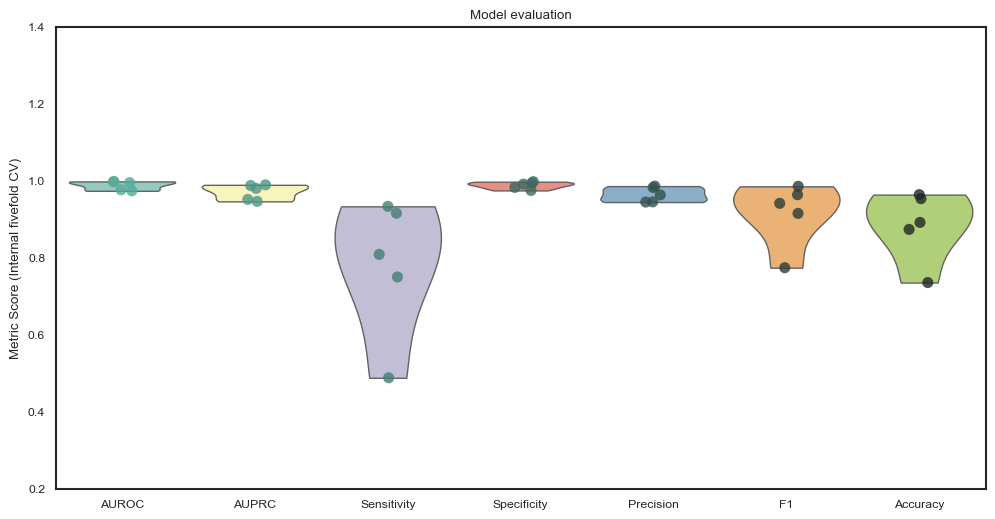

In [ ]:
df_metrics = pd.DataFrame(metrics)
df_metrics_melted = df_metrics.melt(var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.violinplot(x='Metric', y='Score', data=df_metrics_melted, inner=None, palette='Set3', cut=0, linewidth=1)
sns.stripplot(x='Metric', y='Score', data=df_metrics_melted, jitter=True, size=8, alpha=0.8, palette='dark:#5A9_r')
plt.ylim(0.2, 1.4)  
plt.title('Model evaluation')
plt.ylabel('Metric Score (Internal fivefold CV)')
plt.xlabel('')
plt.xticks(rotation=0)

In [99]:
df_metrics

,AUROC,AUPRC,Sensitivity,Specificity,Precision,F1,Accuracy
0,0.996844,0.979609,0.932985,0.993876,0.962730,0.984950,0.963431
1,0.994583,0.987048,0.915104,0.990583,0.981963,0.963178,0.952843
2,0.997697,0.988869,0.749389,0.996991,0.985544,0.940849,0.873190
3,0.973381,0.945852,0.487702,0.982283,0.944585,0.773622,0.734992
4,0.975930,0.951002,0.808173,0.974318,0.944088,0.914610,0.891245


In [ ]:
for i, metric in enumerate(df_metrics.columns):
    plt.text(i, 1.2, 'ns', ha='center', va='center', fontsize=10)
plt.savefig('cv_performance.svg', format='svg', dpi=300)
plt.close()

C:\Users\wenzh\AppData\Local\Temp\ipykernel_4888\1176625325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Score', data=df_metrics_melted, inner=None, palette='Set3', cut=0, linewidth=1)
C:\Users\wenzh\AppData\Local\Temp\ipykernel_4888\1176625325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Metric', y='Score', data=df_metrics_melted, jitter=True, size=8, alpha=0.8, palette='dark:#5A9_r')


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'AUROC'),
  Text(1, 0, 'AUPRC'),
  Text(2, 0, 'Sensitivity'),
  Text(3, 0, 'Specificity'),
  Text(4, 0, 'Precision'),
  Text(5, 0, 'F1'),
  Text(6, 0, 'Accuracy')])

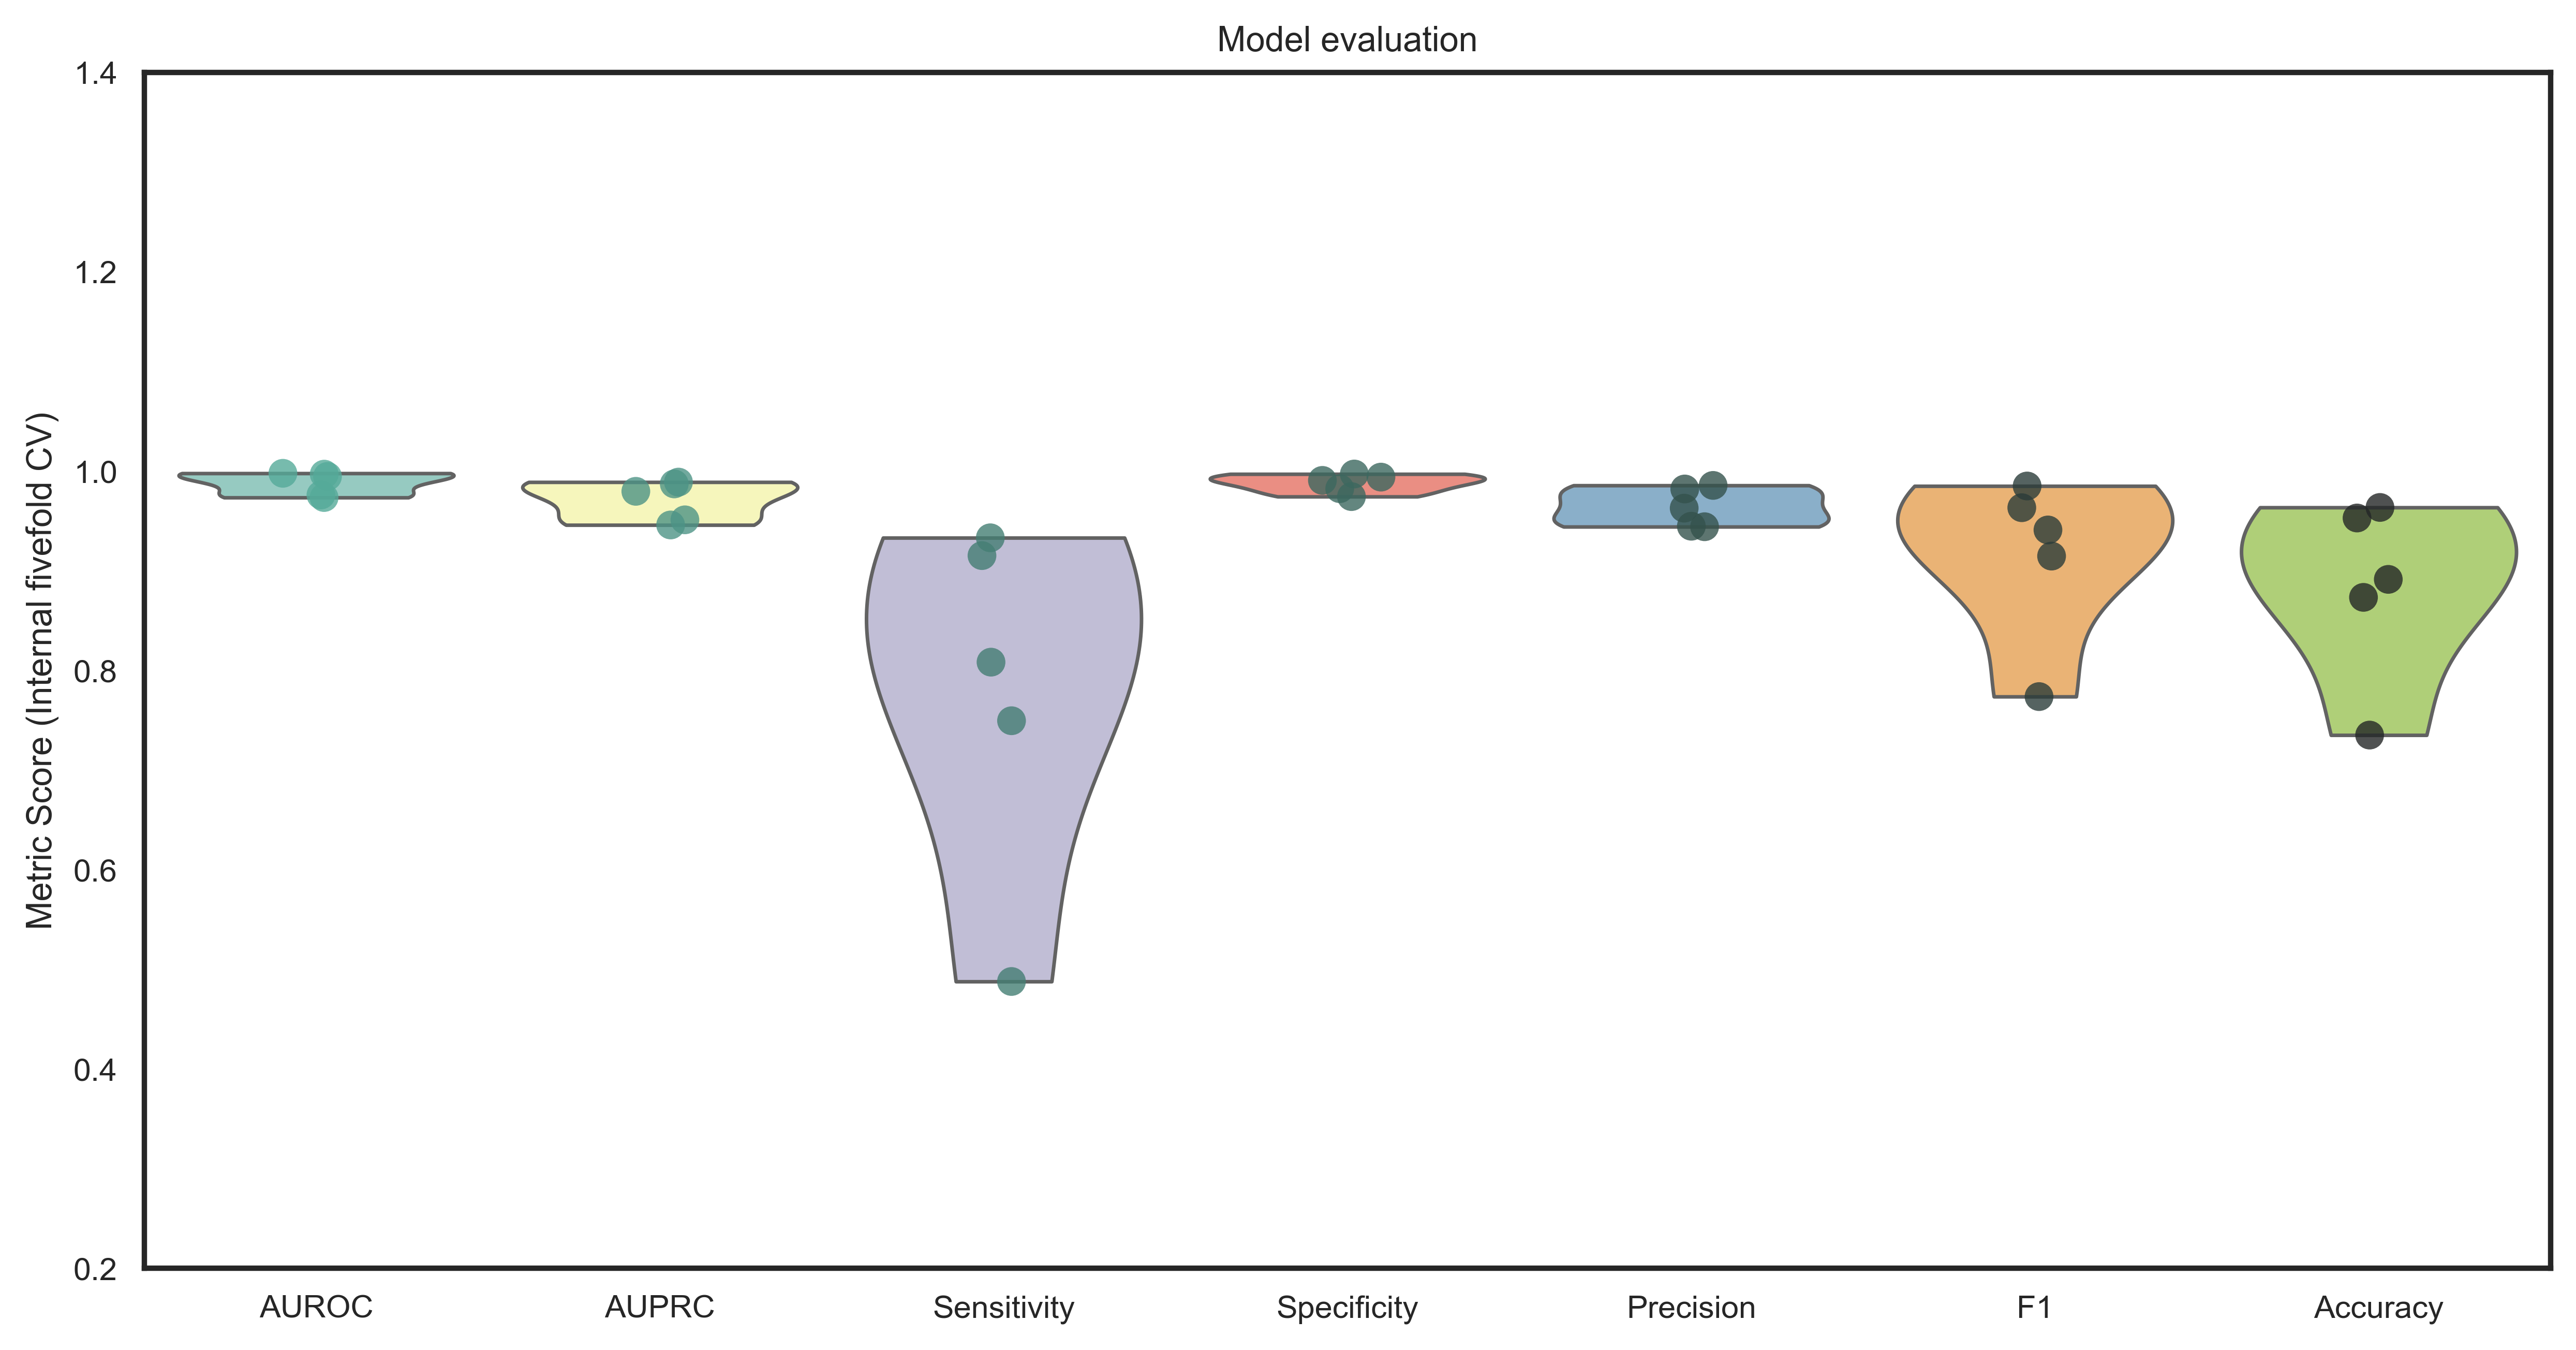

In [95]:
# Plotting
plt.figure(figsize=(12, 6), dpi=500)
sns.violinplot(x='Metric', y='Score', data=df_metrics_melted, inner=None, palette='Set3', cut=0, linewidth=1)
sns.stripplot(x='Metric', y='Score', data=df_metrics_melted, jitter=True, size=8, alpha=0.8, palette='dark:#5A9_r')
plt.ylim(0.2, 1.4)  # Similar y-axis range as in your image
plt.title('Model evaluation')
plt.ylabel('Metric Score (Internal fivefold CV)')
plt.xlabel('')
plt.xticks(rotation=0)

In [38]:
path = r'C:\Users\wenzh\Desktop\deep_learning\Molecular cancer\results'
os.makedirs(path, exist_ok=True)  # Create

In [40]:
# Cross-validation loop
all_roc_aucs = []
all_pr_aucs = []
all_test_accuracies = []
all_test_f1s = []

In [42]:
for fold in range(1, folds + 1):
    print(f"\n=== Fold {fold} ===")
    train_col = f'Train_{fold}'
    test_col = f'Test_{fold}'
    train_patients = cv_df[train_col].dropna().tolist()
    test_patients = cv_df[test_col].dropna().tolist()
    train_ids = [sid for pid in train_patients for sid in patient_ids_to_samples.get(pid, [])]
    test_ids = [sid for pid in test_patients for sid in patient_ids_to_samples.get(pid, [])]
    train_set = combined_df[combined_df['ID'].isin(train_ids)].copy()
    test_set = combined_df[combined_df['ID'].isin(test_ids)].copy()
    to_idx_train, Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, y_train = pretreatment(train_set, is_train=True)
    trav_to_idx, traj_to_idx, trbv_to_idx, trbd_to_idx, trbj_to_idx, cell_to_idx = to_idx_train
    to_idx_test, Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, y_test = pretreatment(test_set,
        trav_to_idx=trav_to_idx, traj_to_idx=traj_to_idx, trbv_to_idx=trbv_to_idx, trbd_to_idx=trbd_to_idx, trbj_to_idx=trbj_to_idx, cell_to_idx=cell_to_idx)
    with open(f'fold_{fold}_mappings.pkl', 'wb') as f:
        pickle.dump(to_idx_train, f)
    train_dataset = TCellDataset(Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, y_train)
    test_dataset = TCellDataset(Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True) 
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    n_genes = Xg_train.shape[1]
    n_trav = len(trav_to_idx)
    n_traj = len(traj_to_idx)
    n_trbv = len(trbv_to_idx)
    n_trbd = len(trbd_to_idx)
    n_trbj = len(trbj_to_idx)
    n_celltype = len(cell_to_idx)
    n_hpvinf = 2
    model = TCellClassifier(n_genes, n_trav, n_traj, n_trbv, n_trbd, n_trbj, n_celltype, n_hpvinf).to(device)
    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
    train_losses_fold = []
    test_losses_fold = []
    test_accuracies_fold = []
    test_f1s_fold = []
    best_test_loss = float('inf')
    epochs = 50
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []
        all_train_probs = []
        train_loop = tqdm(train_loader, leave=False, desc=f"Fold {fold} Epoch {epoch} 训练")
        for batch_idx, batch in enumerate(train_loop):
            Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
            Xg = Xg.to(device)
            Xct = Xct.to(device)
            Xcell = Xcell.to(device)
            Xhpv = Xhpv.to(device)
            Xa = Xa.to(device)
            Xb = Xb.to(device)
            Xal = Xal.to(device)
            Xbl = Xbl.to(device)
            labels = labels.to(device)
            logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xg.size(0)
            preds = torch.argmax(logits, dim=1)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            all_train_probs.extend(probs.detach().cpu().numpy())
            train_loop.set_postfix(loss=loss.item())
        train_loss = running_loss / len(train_dataset)
        train_losses_fold.append(train_loss)
        # Compute train metrics
        train_fpr, train_tpr, _ = roc_curve(all_train_labels, all_train_probs)
        train_roc_auc = auc(train_fpr, train_tpr)
        train_precision, train_recall, _ = precision_recall_curve(all_train_labels, all_train_probs)
        train_pr_auc = auc(train_recall, train_precision)
        model.eval()
        test_loss = 0.0
        all_test_preds = []
        all_test_labels = []
        all_test_probs = []
        with torch.no_grad():
            test_loop = tqdm(test_loader, leave=False, desc=f"Fold {fold} Epoch {epoch} training")
            for batch in test_loop:
                Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl, labels = batch
                Xg = Xg.to(device); Xct = Xct.to(device); Xcell = Xcell.to(device)
                Xhpv = Xhpv.to(device); Xa = Xa.to(device); Xb = Xb.to(device)
                Xal = Xal.to(device); Xbl = Xbl.to(device)
                labels = labels.to(device)
                logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
                loss = criterion(logits, labels)
                test_loss += loss.item() * Xg.size(0)
                preds = torch.argmax(logits, dim=1)
                probs = torch.softmax(logits, dim=1)[:, 1]
                all_test_preds.extend(preds.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                all_test_probs.extend(probs.cpu().numpy())
        avg_test_loss = test_loss / len(test_dataset)
        test_losses_fold.append(avg_test_loss)
        test_acc = np.mean(np.array(all_test_preds) == np.array(all_test_labels))
        test_report = classification_report(all_test_labels, all_test_preds, output_dict=True)
        test_f1 = test_report['macro avg']['f1-score']
        test_f1s_fold.append(test_f1)
        test_accuracies_fold.append(test_acc)
        # Compute test metrics
        test_fpr, test_tpr, _ = roc_curve(all_test_labels, all_test_probs)
        test_roc_auc = auc(test_fpr, test_tpr)
        test_precision, test_recall, _ = precision_recall_curve(all_test_labels, all_test_probs)
        test_pr_auc = auc(test_recall, test_precision)
        # Plot ROC
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(train_fpr, train_tpr, color='#1f77b4', lw=3, label=f'Train (AUC = {train_roc_auc:.2f})')
        ax.plot(test_fpr, test_tpr, color='#ff7f0e', lw=2, label=f'Test (AUC = {test_roc_auc:.2f})')
        ax.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'Fold {fold} Epoch {epoch} ROC Curve')
        ax.legend(loc='lower right', frameon=False)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{path}\\fold_{fold}_roc_epoch_{epoch}.svg')
        plt.close()
        # Plot PR
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(train_recall, train_precision, color='#1f77b4', lw=3, label=f'Train (AP = {train_pr_auc:.2f})')
        ax.plot(test_recall, test_precision, color='#ff7f0e', lw=2, label=f'Test (AP = {test_pr_auc:.2f})')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'Fold {fold} Epoch {epoch} PR Curve')
        ax.legend(loc='lower left', frameon=False)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{path}\\fold_{fold}_pr_epoch_{epoch}.svg')
        plt.close()
        # Plot CM
        cm = confusion_matrix(all_test_labels, all_test_preds)
        fig, ax = plt.subplots(figsize=(5, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'Fold {fold} Epoch {epoch} Confusion Matrix')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig(f'{path}\\fold_{fold}_cm_epoch_{epoch}.svg')
        plt.close()
        # Plot loss evolution
        fig, ax = plt.subplots(figsize=(5, 5))
        epochs_range = range(1, epoch + 1)
        ax.plot(epochs_range, train_losses_fold[:epoch], color='#1f77b4', lw=2, label='Train Loss')
        ax.plot(epochs_range, test_losses_fold[:epoch], color='#ff7f0e', lw=2, label='Test Loss')
        if test_losses_fold:
            min_test = min(test_losses_fold[:epoch])
            max_test = max(test_losses_fold[:epoch])
            margin = (max_test - min_test) * 0.1 + 0.001
            ax.set_ylim(min_test - margin, max_test + margin)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'Fold {fold} Loss Evolution')
        ax.legend(frameon=False)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{path}\\fold_{fold}_loss_evolution_epoch_{epoch}.svg')
        plt.close()
        # Plot metrics evolution
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(epochs_range, test_accuracies_fold[:epoch], color='#2ca02c', lw=2, label='Test Acc')
        ax.plot(epochs_range, test_f1s_fold[:epoch], color='#9467bd', lw=2, label='Test F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Metric')
        ax.set_title(f'Fold {fold} Metrics Evolution')
        ax.legend(frameon=False)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{path}\\fold_{fold}_metrics_evolution_epoch_{epoch}.svg')
        plt.close()
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
    all_roc_aucs.append(test_roc_auc)
    all_pr_aucs.append(test_pr_auc)
    all_test_accuracies.append(test_acc)
    all_test_f1s.append(test_f1)


=== Fold 1 ===



=== Fold 2 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le


=== Fold 3 ===



=== Fold 4 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le


=== Fold 5 ===


C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wenzh\anaconda3\envs\deep_learning_TR\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

In [52]:
# Loading cross validation groups
cv_df = pd.read_csv('Loading cross validation groups.csv')
folds = 5 

In [43]:
# Cross-validation complete, summarize each model's performance
print("\n=== Each model's performance parameter ===")
for fold in range(1, folds + 1):
    print(f"Fold {fold}:")
    print(f"ROC AUC: {all_roc_aucs[fold-1]:.4f}")
    print(f"PR AUPRC: {all_pr_aucs[fold-1]:.4f}")
    print(f"Test accuracy: {all_test_accuracies[fold-1]:.4f}")
    print(f"Test F1: {all_test_f1s[fold-1]:.4f}")
    print("---")


=== Each model's performance parameter ===
Fold 1:
ROC AUC: 0.9964
PR AUPRC: 0.9861
Test accuracy: 0.9861
Test F1: 0.9711
---
Fold 2:
ROC AUC: 0.9972
PR AUPRC: 0.9917
Test accuracy: 0.9784
Test F1: 0.9764
---
Fold 3:
ROC AUC: 0.9970
PR AUPRC: 0.9887
Test accuracy: 0.9754
Test F1: 0.9623
---
Fold 4:
ROC AUC: 0.9824
PR AUPRC: 0.9611
Test accuracy: 0.8275
Test F1: 0.7972
---
Fold 5:
ROC AUC: 0.9869
PR AUPRC: 0.9643
Test accuracy: 0.9268
Test F1: 0.9166
---


In [44]:
best_fold = np.argmax(all_test_f1s) + 1
print(f"Best fold: Fold {best_fold}, F1: {all_test_f1s[best_fold-1]:.4f}")

Best fold: Fold 2, F1: 0.9764


In [45]:
# Cross-validation complete, average metrics summarized
print("\n=== Cross-validation summary ===")
print(f"Average ROC AUC: {np.mean(all_roc_aucs):.4f}")
print(f"Average PR AUPRC: {np.mean(all_pr_aucs):.4f}")
print(f"Average test accuracy: {np.mean(all_test_accuracies):.4f}")
print(f"Average test F1: {np.mean(all_test_f1s):.4f}")


=== Cross-validation summary ===
Average ROC AUC: 0.9920
Average PR AUPRC: 0.9784
Average test accuracy: 0.9388
Average test F1: 0.9247


In [46]:
# Load the mapping of the optimal fold (not params, because params is calculated from the mapping)
with open(f'fold_{best_fold}_mappings.pkl', 'rb') as f:
    to_idx_train = pickle.load(f)
trav_to_idx, traj_to_idx, trbv_to_idx, trbd_to_idx, trbj_to_idx, cell_to_idx = to_idx_train

In [47]:
# Reconstruct params (calculated from mapping)
params = {
    'n_genes': n_genes,  
    'n_trav': len(trav_to_idx),
    'n_traj': len(traj_to_idx),
    'n_trbv': len(trbv_to_idx),
    'n_trbd': len(trbd_to_idx),
    'n_trbj': len(trbj_to_idx),
    'n_celltype': len(cell_to_idx),
    'n_hpvinf': 2
}

In [48]:
model = TCellClassifier(**params).to(device)
model.load_state_dict(torch.load(f'best_model_fold_{best_fold}.pth'))
model.eval()

TCellClassifier(
  (embed_trav): Embedding(48, 32)
  (embed_traj): Embedding(53, 32)
  (embed_trbv): Embedding(50, 32)
  (embed_trbd): Embedding(4, 32)
  (embed_trbj): Embedding(14, 32)
  (embed_cell): Embedding(11, 8)
  (embed_hpv): Embedding(2, 2)
  (embed_aa_properties): Embedding(6, 32, padding_idx=0)
  (transformer_alpha): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
    (linear1): Linear(in_features=32, out_features=2048, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (linear2): Linear(in_features=2048, out_features=32, bias=True)
    (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
  )
  (transformer_beta): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj

In [ ]:
# Prediction on unknown data
unknown_df = pd.read_csv('./data/unknown_cells_input.csv')
unknown_df['CTgene'] = unknown_df['CTgene'].str.replace('_', '.', regex=False)  # Ensure consistency

In [ ]:
# Use training mappings for prediction
to_idx_unknown, X_genes, X_ctgene, X_celltype, X_hpvinf, X_seq_alpha_props, X_seq_beta_props, X_seq_alpha_len, X_seq_beta_len, _ = pretreatment(unknown_df, 
    trav_to_idx=trav_to_idx, traj_to_idx=traj_to_idx, trbv_to_idx=trbv_to_idx, trbd_to_idx=trbd_to_idx, trbj_to_idx=trbj_to_idx, cell_to_idx=cell_to_idx)

In [ ]:
unknown_dataset = TCellDataset(X_genes, X_ctgene, X_celltype, X_hpvinf, X_seq_alpha_props, X_seq_beta_props, X_seq_alpha_len, X_seq_beta_len)
unknown_loader = DataLoader(unknown_dataset, batch_size=256, shuffle=False)

In [ ]:
model.eval()
all_preds = []
with torch.no_grad():
    for batch in unknown_loader:
        Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl = [x.to(device) for x in batch]
        logits = model(Xg, Xct, Xcell, Xhpv, Xa, Xb, Xal, Xbl)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

In [ ]:
unknown_df['predicted_label'] = all_preds
result_df = unknown_df[['ID', 'predicted_label']]
result_df['predicted_label'] = result_df['predicted_label'].map({0: 'nonNeo', 1: 'Neo'})
result_df.to_csv('predicted_unknown_cells.csv', index=False)
print("Prediction completed and results saved to 'predicted_unknown_cells.csv'.")